<a href="https://colab.research.google.com/github/ICam99/cdsi2025/blob/main/proyecto/clasificacionSonidosAmbientales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de sonidos ambientales para detección de eventos

### Configuración inicial (instalaciones, importar librerías, configurar variables)

In [1]:
!apt-get install libportaudio2 portaudio19-dev

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libportaudio2 is already the newest version (19.6.0-1.1).
portaudio19-dev is already the newest version (19.6.0-1.1).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.


In [2]:
# Instalar librerías necesarias
!pip install pydub librosa sounddevice numpy matplotlib tensorflow scikit-learn sounddevice

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import librosa
import librosa.display
import soundfile as sf
import sounddevice as sd
import queue
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from pydub import AudioSegment

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Configuración
AUDIO_DIR = '/content/drive/MyDrive/CDSI/proyecto/audiosProyecto'
SAMPLE_RATE = 22050
DURATION = 2  # segundos
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION

# Configuración
SEGMENT_LENGTH = 2  # segundos
OVERLAP = 0.1       # 10% de overlap
MIN_RMS = 0.001      # Umbral mínimo de energía para considerar un segmento válido

### Funciones para pre-procesamiento

In [6]:
def generate_atypical_sounds(num_sounds, output_dir):
    """Genera sonidos atípicos sintéticamente y los guarda en un directorio.

    Args:
        num_sounds: El número de sonidos atípicos a generar.
        output_dir: El directorio donde se guardarán los sonidos.
    """

    os.makedirs(output_dir, exist_ok=True)

    for i in range(num_sounds):
        # Generar ruido blanco
        noise = np.random.rand(SAMPLE_RATE * DURATION)

        # Aplicar efectos (opcional)
        # noise = librosa.effects.time_stretch(noise, rate=1.2)  # Ejemplo: Time stretch

        # Guardar el sonido
        file_path = os.path.join(output_dir, f'atypical_{i}.wav')
        sf.write(file_path, noise, SAMPLE_RATE)

In [7]:
# Generar 100 sonidos atípicos en la carpeta 'atípico'
generate_atypical_sounds(100, os.path.join(AUDIO_DIR, 'atípico'))

Comenzamos definiendo una función para cargar los datos recolectados. Los datos se encuentran en una carpeta en Google Drive, separados por evento. La función carga los audios para poder trabajar con ellos en el notebook. La manera en la que los carga es la siguiente: para cada audio donde se detecte un umbral RMS (root mean square) mayor a 0.001, lo convierte en segmentos de 2 segundos, con 0.2 segundos de *overlap* entre ellos. La función tambien nos dejará visualizar los datos (ondas de audio, espectrograma de Mel, y umbral RMS).

In [8]:
def load_data(data_path, segment_length=2, overlap=0.1, min_rms=0.001, visualize=True):
    """
    Carga archivos de audio y los divide en segmentos con overlap
    Argumentos:
        data_path: Ruta a la carpeta de audios
        segment_length: Duración de cada segmento en segundos (default: 2)
        overlap: Porcentaje de overlap entre segmentos (0-1, default: 0.5)
        min_rms: Valor mínimo de RMS para considerar un segmento no silencioso
        visualize: Si True, muestra ejemplos visuales de los segmentos
    Returns:
        X: Características
        y: Etiquetas
        labels: Nombres de las clases
    """
    # Encontrar todas las categorías (carpetas)
    labels = [name for name in os.listdir(data_path)
              if os.path.isdir(os.path.join(data_path, name))]

    features = []
    categories = []
    samples_per_segment = int(SAMPLE_RATE * segment_length)
    step_size = int(samples_per_segment * (1 - overlap))

    # Muestra un ejemplo por clase
    examples_to_show = 1
    examples_shown = {label: 0 for label in labels}

    for label in labels:
        label_path = os.path.join(data_path, label)
        audio_files = [f for f in os.listdir(label_path) if f.endswith('.m4a') or f.endswith('.wav')]

        for audio_file in audio_files:
            file_path = os.path.join(label_path, audio_file)

            try:
                # Convertir m4a a wav si es necesario
                if file_path.endswith('.m4a'):
                    sound = AudioSegment.from_file(file_path, format='m4a')
                    file_path = file_path.replace('.m4a', '.wav')
                    sound.export(file_path, format='wav')

                # Cargar audio
                signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)

                # Calcular número de segmentos posibles
                num_segments = int((len(signal) - samples_per_segment) / step_size) + 1

                for i in range(num_segments):
                    # Extraer segmento
                    start = i * step_size
                    end = start + samples_per_segment
                    segment = signal[start:end]

                    # Si el segmento es más corto, rellenar con ceros
                    if len(segment) < samples_per_segment:
                        padding = samples_per_segment - len(segment)
                        segment = np.pad(segment, (0, padding), mode='constant')

                    # Ignorar segmentos silenciosos
                    rms = librosa.feature.rms(y=segment).mean()
                    if rms < min_rms:
                        continue

                    # Extraer mel-spectrogram
                    mel_spectrogram = librosa.feature.melspectrogram(y=segment, sr=sr, n_mels=128, fmax=8000)
                    log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

                    features.append(log_mel_spectrogram)
                    categories.append(label)

                    # Visualización de ejemplos
                    if visualize and examples_shown[label] < examples_to_show:
                        plt.figure(figsize=(15, 5))

                        # Onda de audio
                        plt.subplot(1, 3, 1)
                        librosa.display.waveshow(segment, sr=sr)
                        plt.title(f'Onda de audio\nClase: {label}\nRMS: {rms:.4f}')

                        # Espectrograma
                        plt.subplot(1, 3, 2)
                        librosa.display.specshow(log_mel_spectrogram, sr=sr, x_axis='time', y_axis='mel')
                        plt.colorbar(format='%+2.0f dB')
                        plt.title('Mel-Spectrogram')

                        # RMS
                        plt.subplot(1, 3, 3)
                        frames = range(len(segment))
                        t = librosa.frames_to_time(frames, sr=sr)
                        plt.plot(t, segment, label='Audio')
                        plt.plot(t, np.ones_like(segment) * min_rms, 'r--', label='Umbral RMS')
                        plt.legend()
                        plt.title('Amplitud vs Umbral')

                        plt.tight_layout()
                        plt.show()

                        examples_shown[label] += 1

            except Exception as e:
                print(f"Error procesando {file_path}: {str(e)}")
                continue

    X = np.array(features)
    y = np.array(categories)

    print(f"\nResumen de datos cargados:")
    print(f"- Total segmentos: {len(X)}")
    print(f"- Distribución por clases:")
    for label in labels:
        print(f"  - {label}: {np.sum(y == label)} segmentos")

    return X, y, labels

### Análisis exploratorio de los datos

A continuación utilizamos nuestra función para poder visualizar los datos con los que trabajaremos. Nos mostrará un ejemplo de como se ve cada clase de audios con las que contamos.

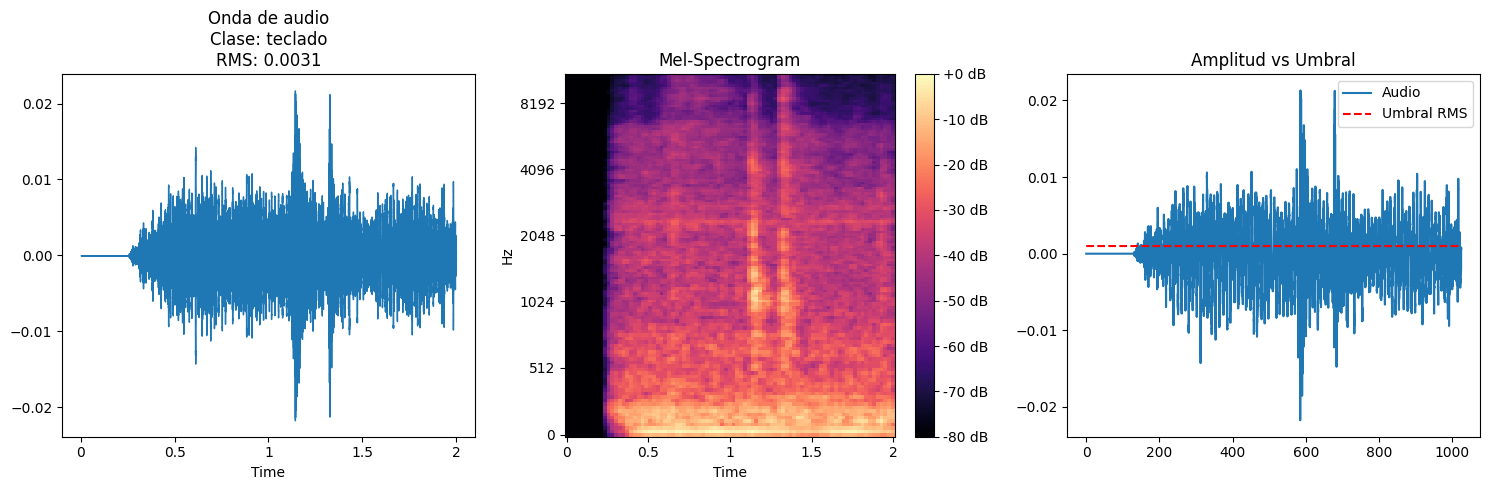

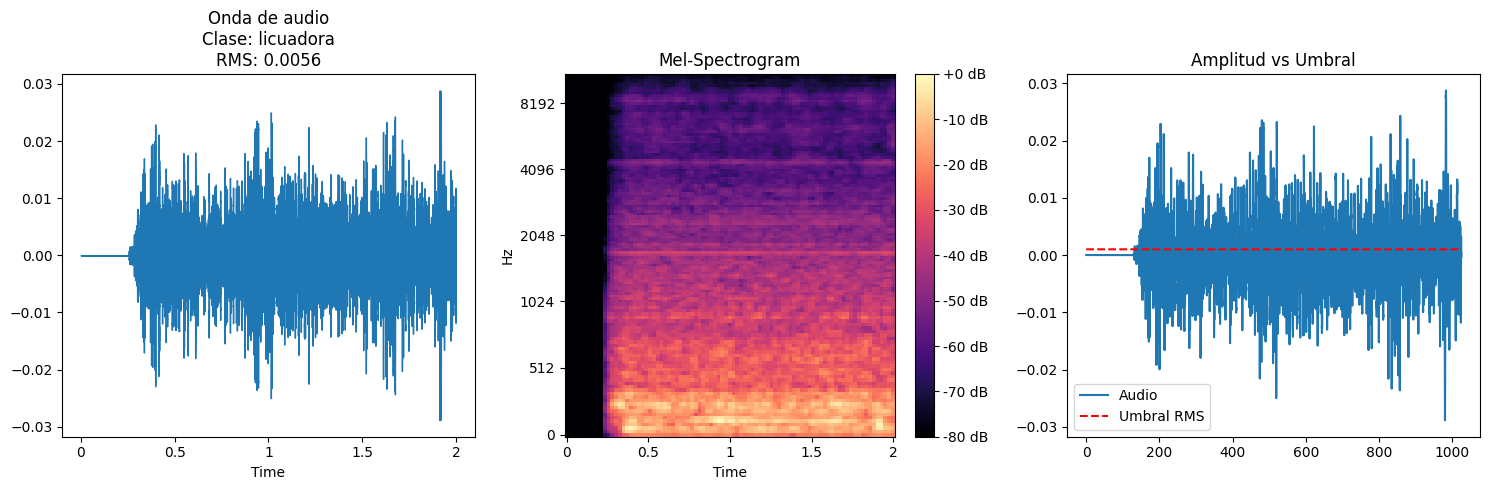

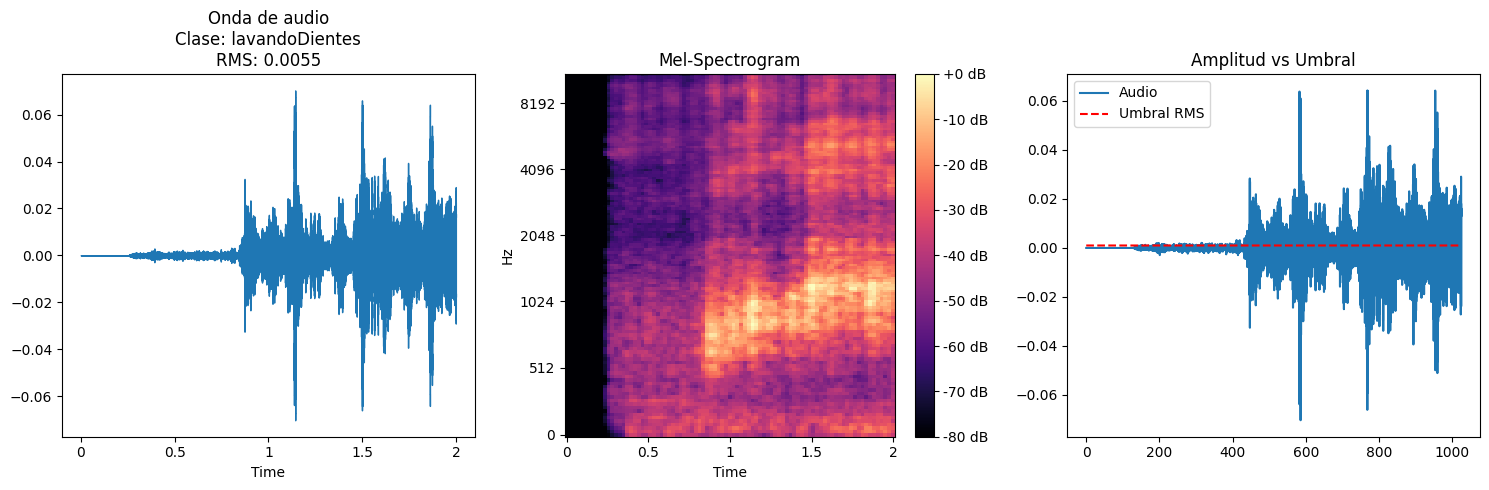

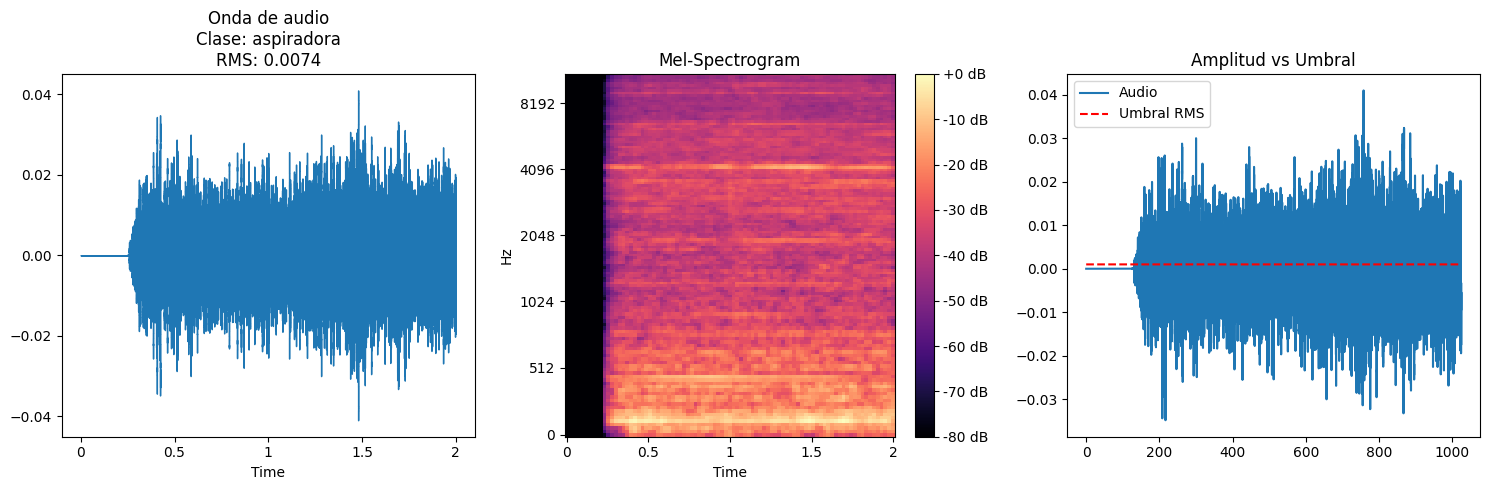

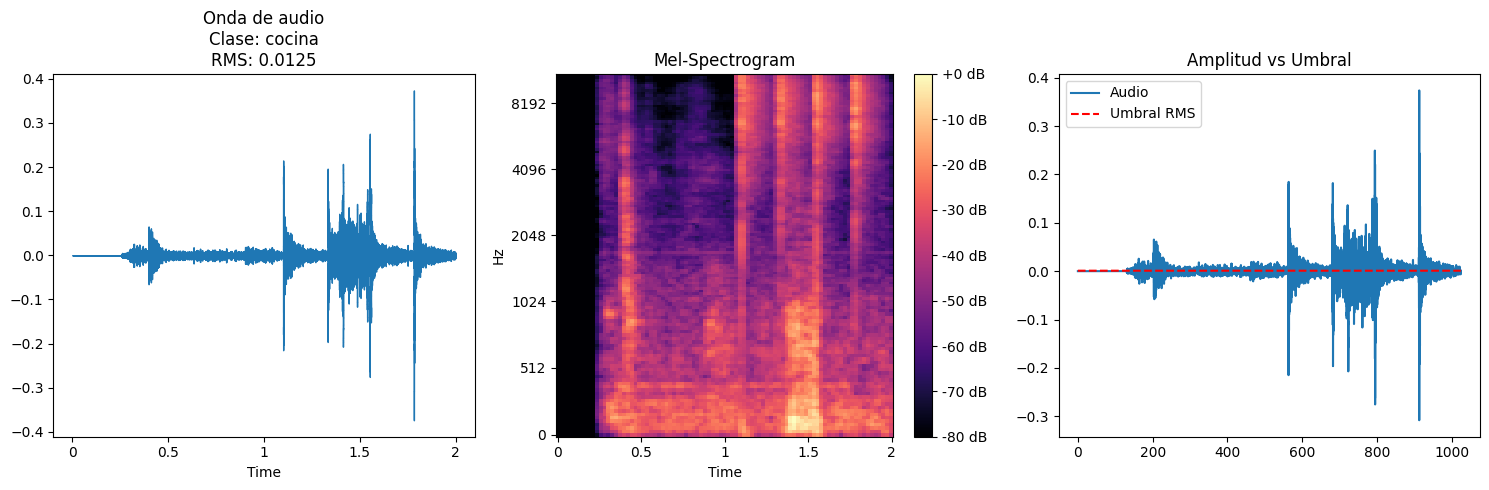

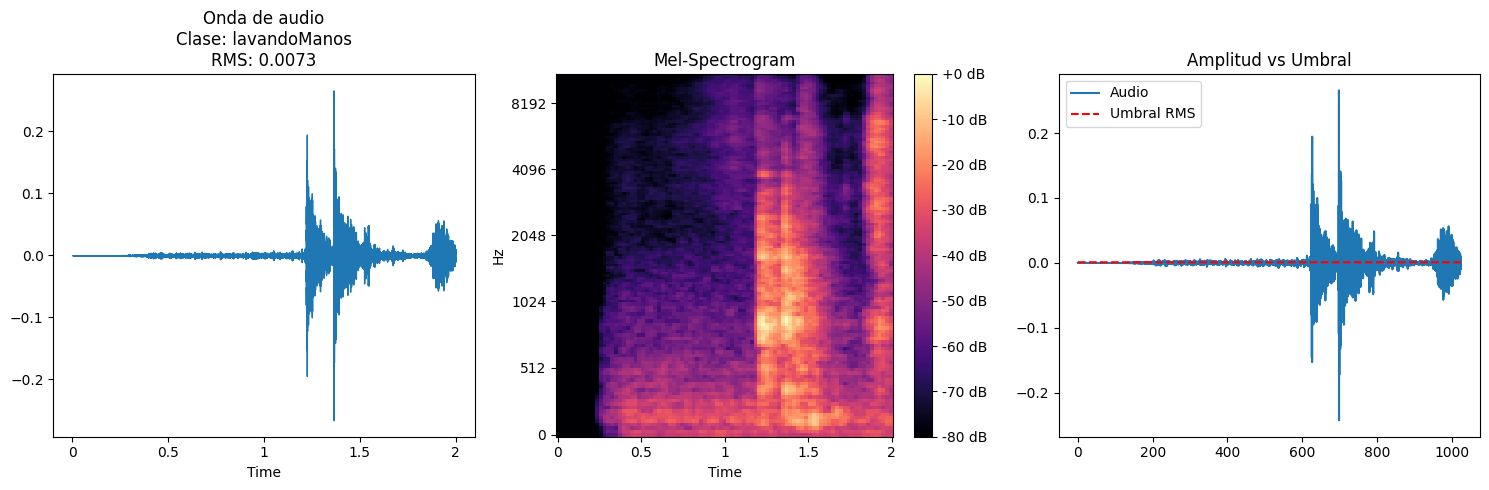

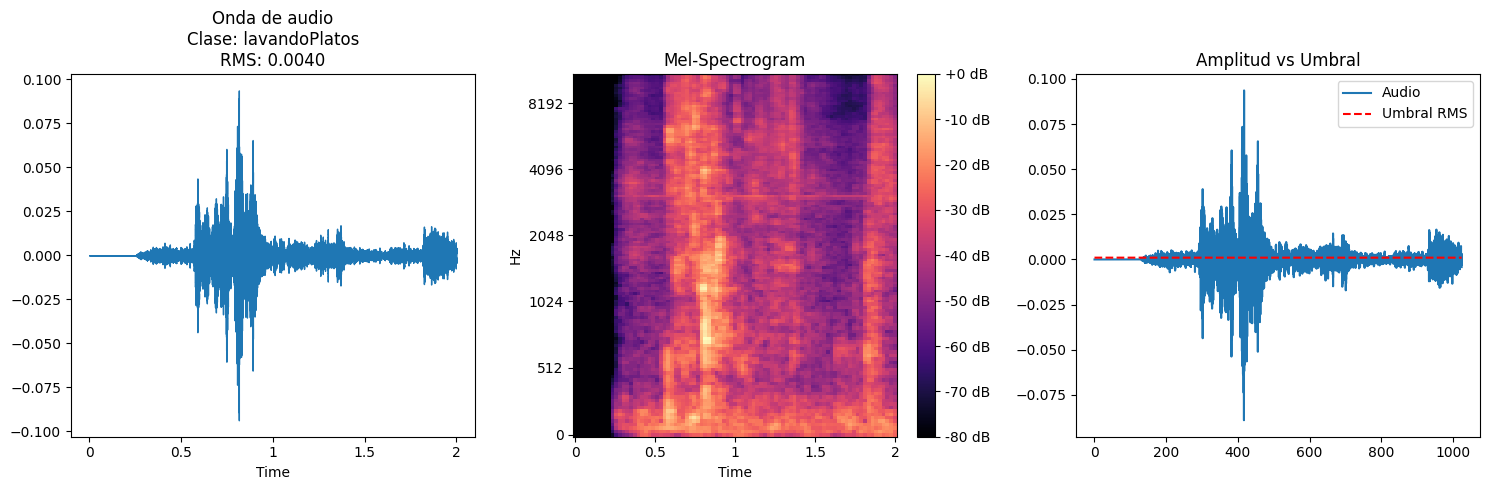

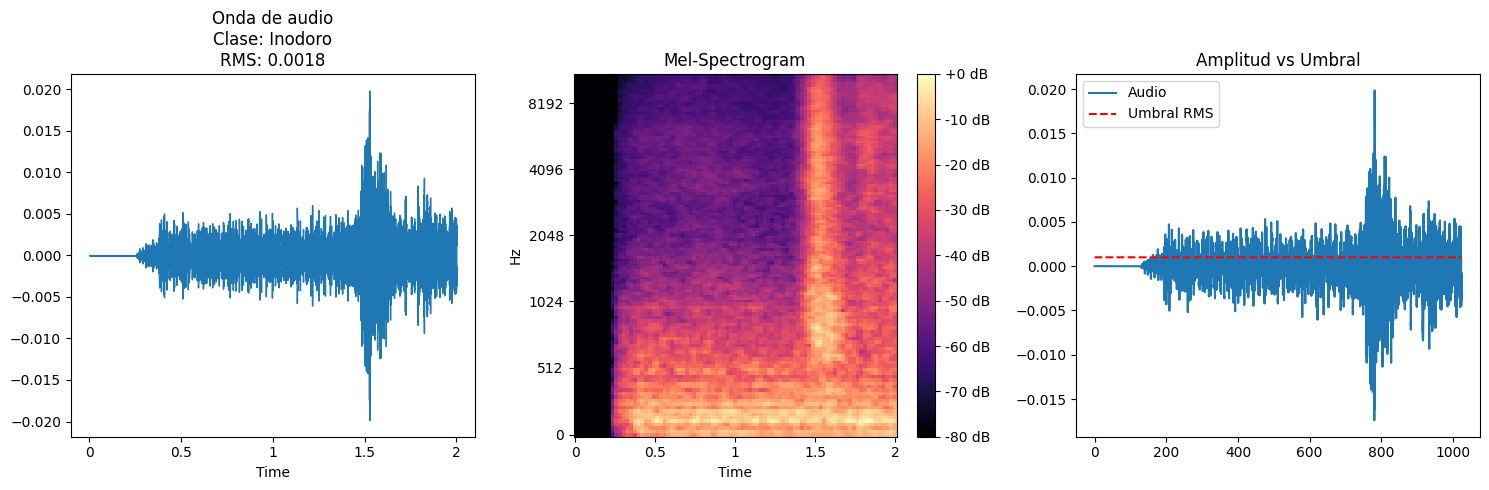

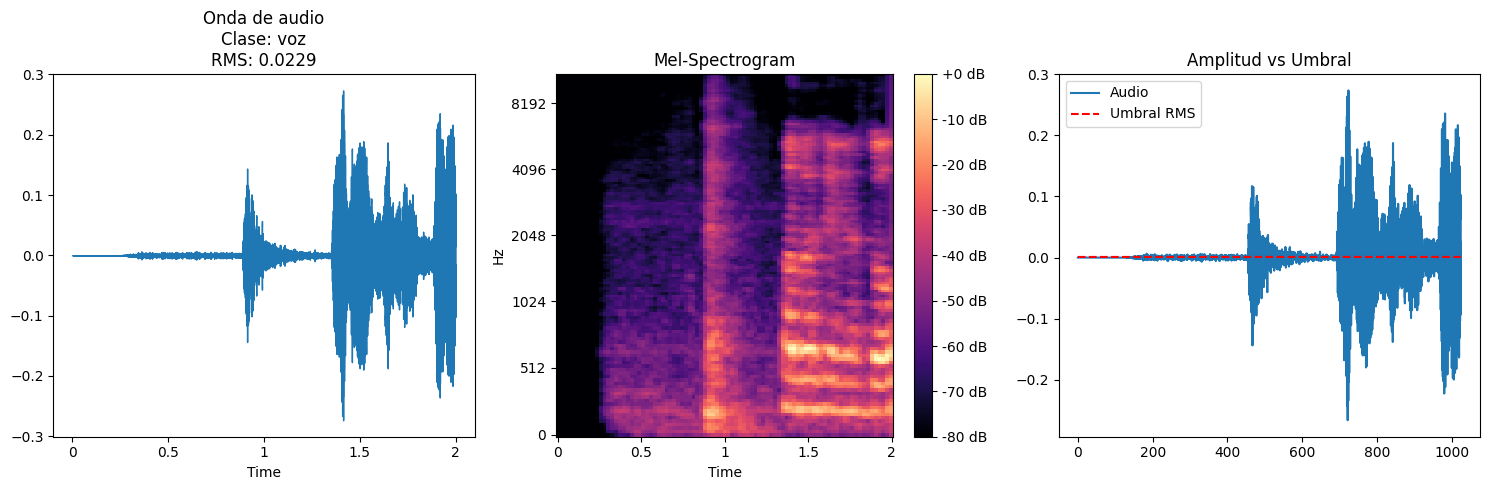

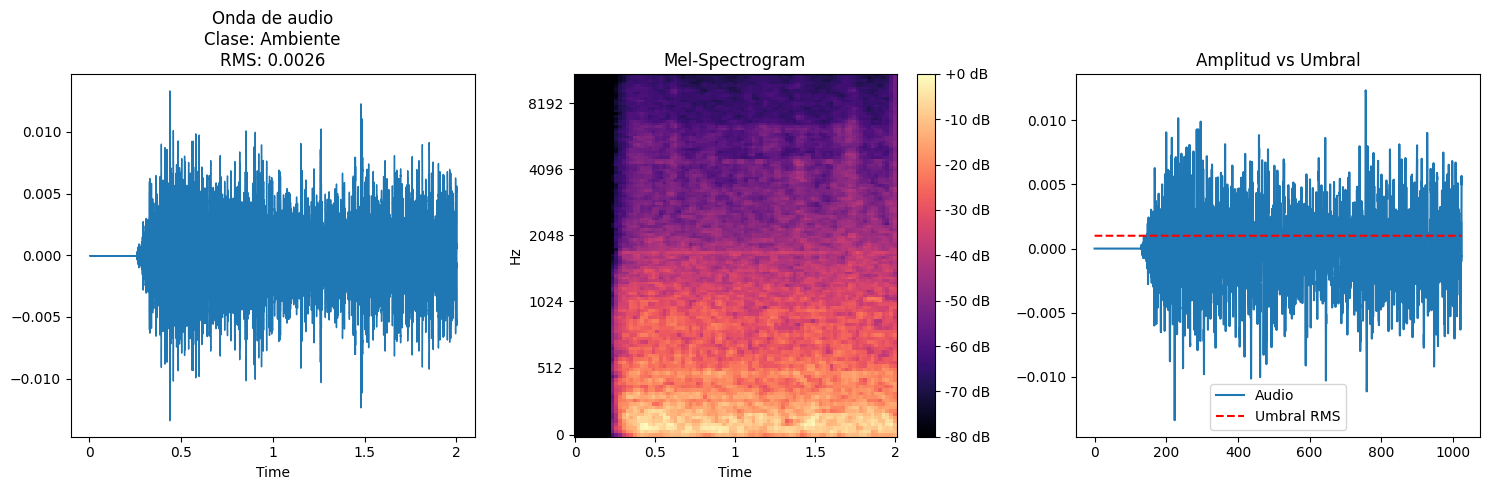

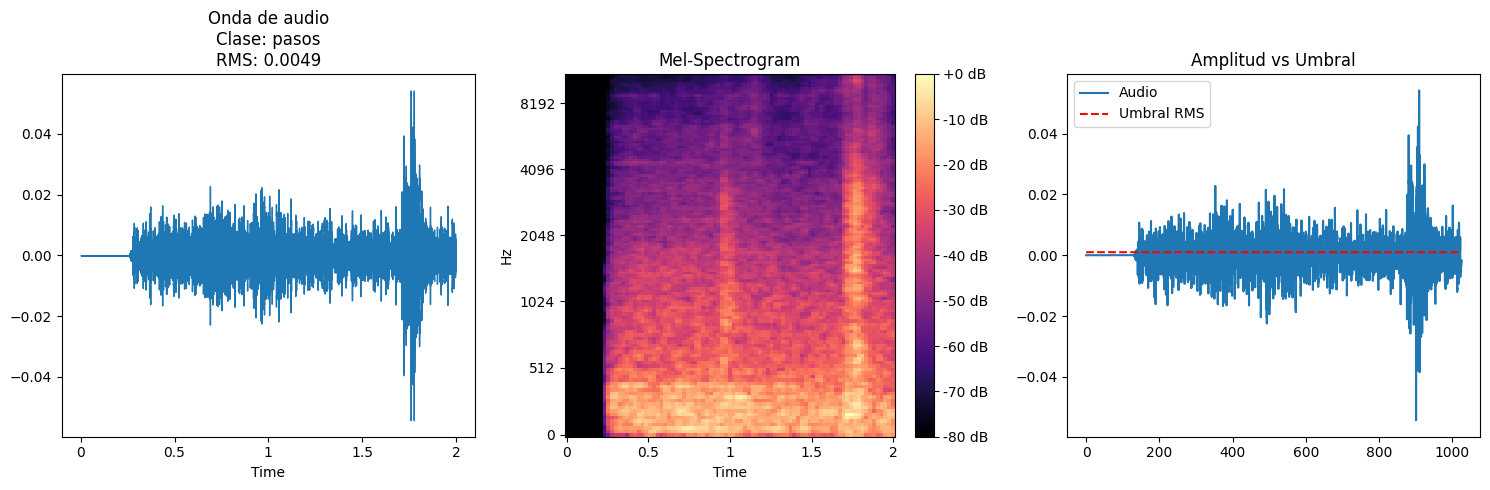

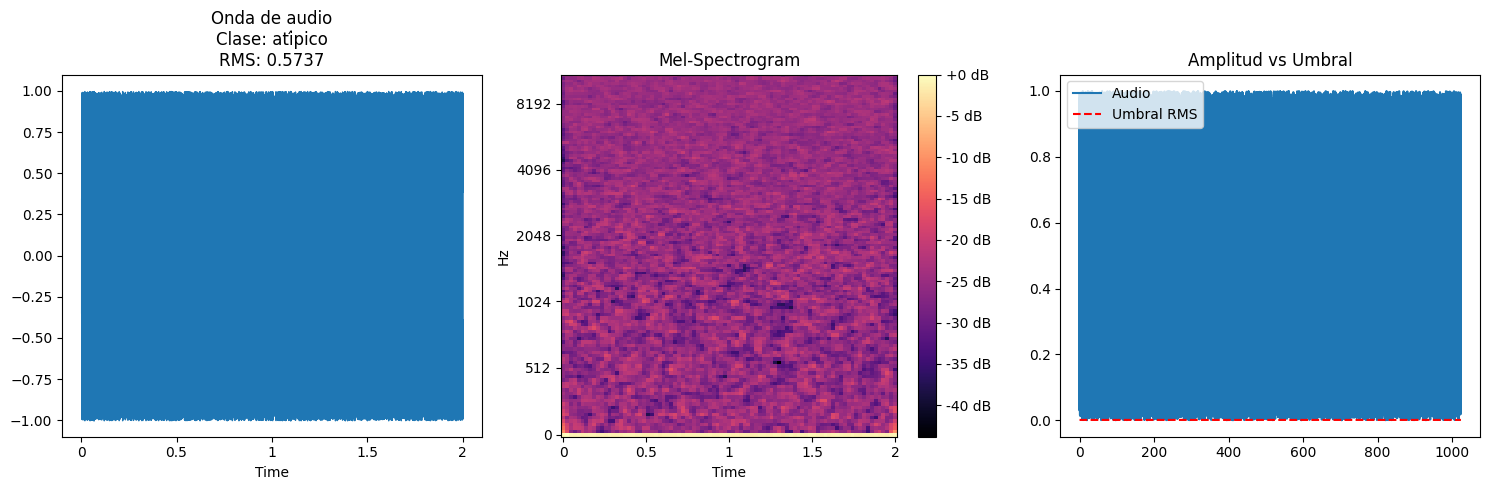

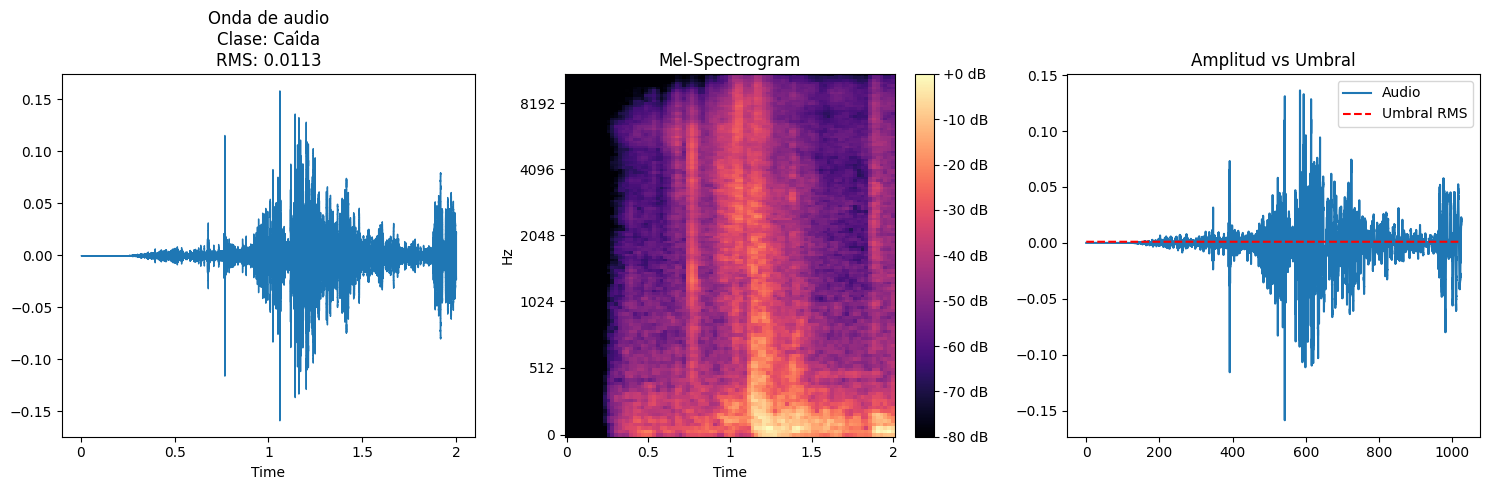

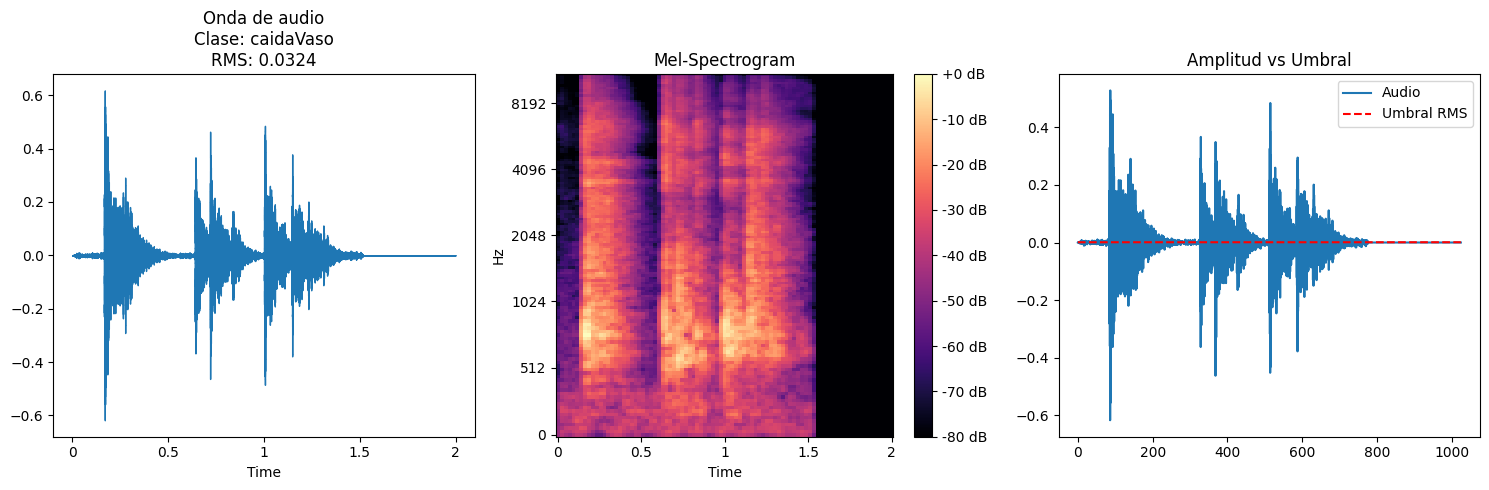


Resumen de datos cargados:
- Total segmentos: 2124
- Distribución por clases:
  - teclado: 332 segmentos
  - licuadora: 24 segmentos
  - lavandoDientes: 48 segmentos
  - aspiradora: 132 segmentos
  - cocina: 514 segmentos
  - lavandoManos: 34 segmentos
  - lavandoPlatos: 464 segmentos
  - Inodoro: 66 segmentos
  - voz: 8 segmentos
  - Ambiente: 330 segmentos
  - pasos: 66 segmentos
  - atípico: 100 segmentos
  - Caída: 3 segmentos
  - caidaVaso: 3 segmentos


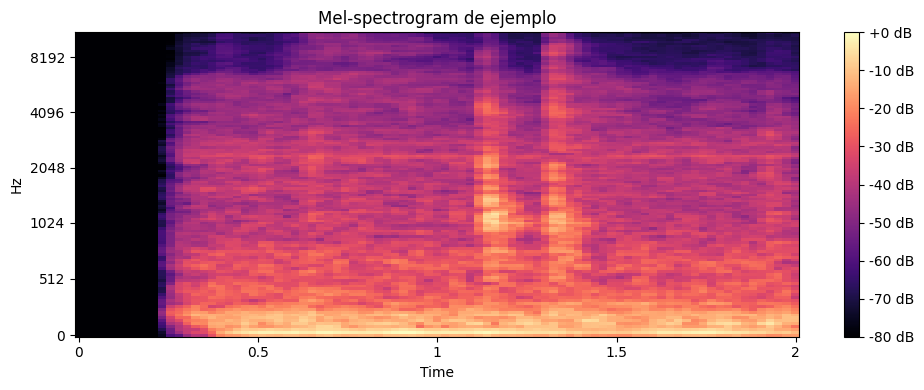

In [9]:
# Cargar datos
X, y, labels = load_data(AUDIO_DIR,
                        segment_length=SEGMENT_LENGTH,
                        overlap=OVERLAP,
                        min_rms=MIN_RMS,
                        visualize=True)

# Visualizar un ejemplo
plt.figure(figsize=(10, 4))
librosa.display.specshow(X[0], sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-spectrogram de ejemplo')
plt.tight_layout()
plt.show()

### Entrenamiento del modelo

Dividimos nuestro dataset en datos de entrenamiento y datos de prueba (20%).

In [10]:
# Añadir dimensión del canal para CNN
X = X[..., np.newaxis]

# Codificar etiquetas
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de y_train: {y_train.shape}")

Forma de X_train: (1699, 128, 87, 1)
Forma de y_train: (1699, 14)


Definimos una función para crear nuestro modelo. El modelo a utilizar será una red neuronal convolucional o CNN.

In [11]:
def build_model(input_shape, num_classes):
    model = Sequential()

    # Primera capa convolucional
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D((2, 2)))
    model.add(BatchNormalization())

    # Segunda capa convolucional
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(BatchNormalization())

    # Tercera capa convolucional
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(BatchNormalization())

    # Cuarta capa convolucional
    model.add(Conv2D(256, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(BatchNormalization())

    # Aplanar y capas densas
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    return model

In [12]:
# Construir modelo
input_shape = X_train.shape[1:]
model = build_model(input_shape, len(labels))

# Compilar modelo
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 85, 32)         │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 42, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 63, 42, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 40, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 20, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 30, 20, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 18, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 9, 128)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 14, 9, 128)          │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 12, 7, 256)          │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 3, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 6, 3, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       1,179,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 14)                  │           3,598 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,573,262 (6.00 MB)

 Trainable params: 1,572,302 (6.00 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 787ms/step - accuracy: 0.4516 - loss: 2.0280
Epoch 1: val_accuracy improved from -inf to 0.25412, saving model to best_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 51s 853ms/step - accuracy: 0.4541 - loss: 2.0171 - val_accuracy: 0.2541 - val_loss: 2.4156
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 988ms/step - accuracy: 0.8332 - loss: 0.5015
Epoch 2: val_accuracy improved from 0.25412 to 0.37647, saving model to best_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.8336 - loss: 0.5009 - val_accuracy: 0.3765 - val_loss: 1.9472
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.9187 - loss: 0.2642
Epoch 3: val_accuracy improved from 0.37647 to 0.73176, saving model to best_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 71s 854ms/step - accuracy: 0.9189 - loss: 0.2638 - val_accuracy: 0.7318 - val_loss: 1.0506
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - accuracy: 0.9613 - loss: 0.1400
Epoch 4: val_accuracy improved from 0.73176 to 0.75529, saving model to best_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 81s 844ms/step - accuracy: 0.9614 - loss: 0.1397 - val_accuracy: 0.7553 - val_loss: 0.7182
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.9557 - loss: 0.1428
Epoch 5: val_accuracy improved from 0.75529 to 0.90118, saving model to best_model.h5


...

54/54 ━━━━━━━━━━━━━━━━━━━━ 82s 852ms/step - accuracy: 0.9975 - loss: 0.0243 - val_accuracy: 0.9765 - val_loss: 0.1053
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.9959 - loss: 0.0321
Epoch 9: val_accuracy improved from 0.97647 to 0.98118, saving model to best_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 85s 903ms/step - accuracy: 0.9959 - loss: 0.0321 - val_accuracy: 0.9812 - val_loss: 0.0485
Epoch 10/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 951ms/step - accuracy: 0.9985 - loss: 0.0155
Epoch 10: val_accuracy improved from 0.98118 to 0.98588, saving model to best_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 54s 998ms/step - accuracy: 0.9985 - loss: 0.0156 - val_accuracy: 0.9859 - val_loss: 0.0314
Epoch 11/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 817ms/step - accuracy: 1.0000 - loss: 0.0157
Epoch 11: val_accuracy did not improve from 0.98588
54/54 ━━━━━━━━━━━━━━━━━━━━ 76s 876ms/step - accuracy: 1.0000 - loss: 0.0157 - val_accuracy: 0.9859 - val_loss: 0.0484
Epoch 12/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 798ms/step - accuracy: 0.9983 - loss: 0.0186
Epoch 12: val_accuracy did not improve from 0.98588
54/54 ━━━━━━━━━━━━━━━━━━━━ 81s 863ms/step - accuracy: 0.9983 - loss: 0.0186 - val_accuracy: 0.9812 - val_loss: 0.0437
Epoch 13/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - accuracy: 0.9972 - loss: 0.0134
Epoch 13: val_accuracy did not improve from 0.98588
54/54 ━━━━━━━━━━━━━━━━━━━━ 82s 866ms/step - accuracy: 0.9972 - loss: 0.0134 - val_accuracy: 0.9859 - val_loss: 0.0238
Epoch 14/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 787ms/step - accuracy: 0.9987 - loss: 0.0089
Epoch 14: val_accuracy d

54/54 ━━━━━━━━━━━━━━━━━━━━ 46s 853ms/step - accuracy: 0.9974 - loss: 0.0107 - val_accuracy: 0.9906 - val_loss: 0.0189
Epoch 19/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 840ms/step - accuracy: 0.9999 - loss: 0.0065
Epoch 19: val_accuracy improved from 0.99059 to 1.00000, saving model to best_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 48s 891ms/step - accuracy: 0.9998 - loss: 0.0065 - val_accuracy: 1.0000 - val_loss: 0.0161
Epoch 20/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 782ms/step - accuracy: 0.9994 - loss: 0.0060
Epoch 20: val_accuracy did not improve from 1.00000
54/54 ━━━━━━━━━━━━━━━━━━━━ 79s 832ms/step - accuracy: 0.9994 - loss: 0.0060 - val_accuracy: 0.9906 - val_loss: 0.0173
Epoch 21/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - accuracy: 1.0000 - loss: 0.0044
Epoch 21: val_accuracy did not improve from 1.00000
54/54 ━━━━━━━━━━━━━━━━━━━━ 88s 944ms/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 0.9906 - val_loss: 0.0267
Epoch 22/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 822ms/step - accuracy: 1.0000 - loss: 0.0028
Epoch 22: val_accuracy did not improve from 1.00000
54/54 ━━━━━━━━━━━━━━━━━━━━ 47s 871ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.9859 - val_loss: 0.0233
Epoch 23/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 800ms/step - accuracy: 1.0000 - loss: 0.0024
Epoch 23: val_accuracy d

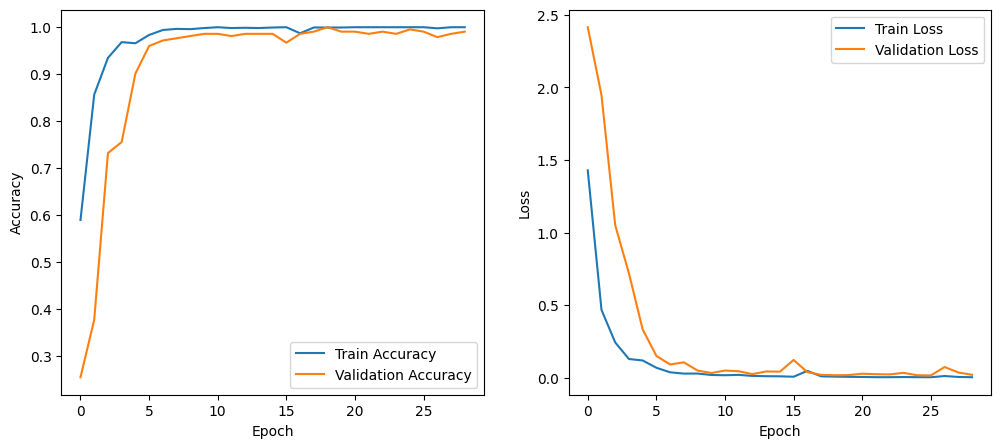

In [13]:
# Callbacks
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy',
                             save_best_only=True, mode='max', verbose=1)
early_stop = EarlyStopping(monitor='val_accuracy', patience=10,
                           restore_best_weights=True)

# Entrenamiento
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=50,
                    batch_size=32,
                    callbacks=[checkpoint, early_stop])

# Graficar resultados
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Resultados

Con nuestro mejor modelo evaluaremos los resultados obtenidos y generamos una matriz de confusión:

14/14 - 2s - 165ms/step - accuracy: 1.0000 - loss: 0.0161

Test accuracy: 1.0000
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 177ms/step

Classification Report:
                precision    recall  f1-score   support

       teclado       1.00      1.00      1.00        66
lavandoDientes       1.00      1.00      1.00        17
    aspiradora       1.00      1.00      1.00        35
        cocina       1.00      1.00      1.00        22
 lavandoPlatos       1.00      1.00      1.00        92
       Inodoro       1.00      1.00      1.00         9
           voz       1.00      1.00      1.00         7
      Ambiente       1.00      1.00      1.00        93
         pasos       1.00      1.00      1.00         4
      atípico       1.00      1.00      1.00        12
        Caída       1.00      1.00      1.00        65
     caidaVaso       1.00      1.00      1.00         3

      accuracy                           1.00       425
     macro avg       1.00      1.00      1.00       425
  weighted a

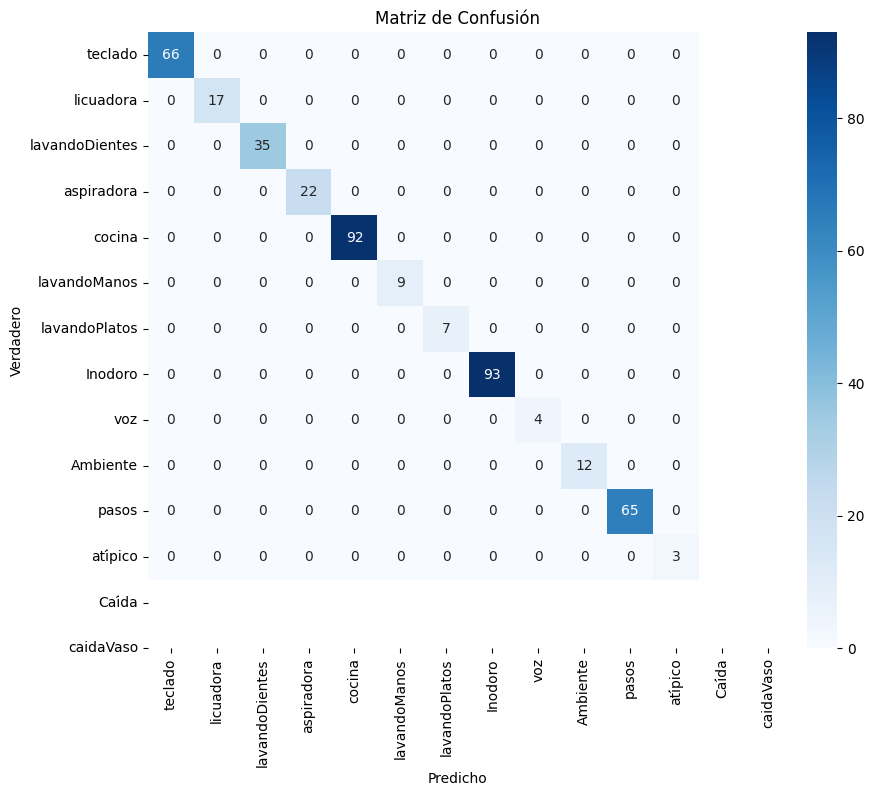

In [14]:
# Cargar el mejor modelo
model.load_weights('best_model.h5')

# Evaluar en test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')

# Reporte de clasificación
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Get unique classes in y_true and y_pred_classes
unique_classes = np.unique(np.concatenate((y_true, y_pred_classes)))

# Filter labels to include only the present classes
present_labels = [labels[i] for i in unique_classes]

print('\nClassification Report:')
print(classification_report(y_true, y_pred_classes, target_names=present_labels))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicho')
plt.ylabel('Verdadero')
plt.title('Matriz de Confusión')
plt.show()

In [15]:
# Guardar el modelo entrenado
model.save('best_model.h5')

# Guardar el label encoder
import pickle
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

# Comprimir todo para descargar
!zip -r model_files.zip best_model.h5 label_encoder.pkl

# Descargar
from google.colab import files
files.download('model_files.zip')

updating: label_encoder.pkl (deflated 65%)
updating: best_model.h5 (deflated 9%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Conclusiones

La detección de eventos a través del sonido es una tarea que es de mucha utilidad para muchas aplicaciones. En cuanto a este proyecto, dado que se trata de detección de sonidos en un ambiente de hogar, tiene aplicación para motivos de seguridad (e.g. detectar intrusos) o para asistencia en los cuidados de una persona mayor o con alguna condición que la haga requerir ayuda. En lo personal este proyecto se tomó en cuenta más para la segunda parte, por lo que se añadieron además de los eventos normales algunos eventos como caída y caída de vasos, que podrían indicar que la persona necesita ayuda.

Se comparte ahora un screenshot de la salida de un script en python que implementa el mejor modelo y detecta los sonidos en tiempo real (en este ejemplo el sonido real era aspiradora):

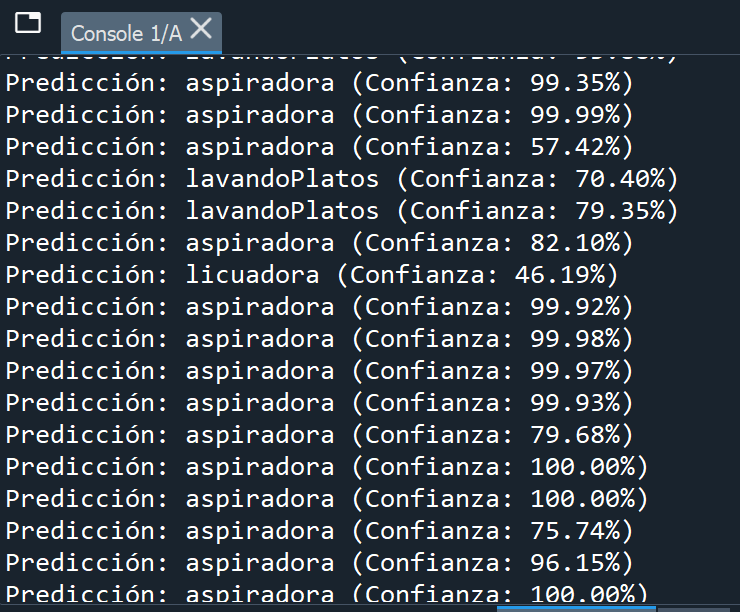

### Notas adicionales:

*   Se escogió cortar los audios en segmentos de 2 segundos ya que de los eventos que se querían clasificar, los más importantes para esta tarea eran de caídas, las cuales toman solo 2 segundos aproximadamente según las muestras obtenidas.
*   También se tomó en cuenta esta duración de 2 segundos para la clasificación de sonidos en tiempo real, ya que si los eventos fueran de mayor duración puede añadir latencia a la detección en tiempo real.